## training an RNN at char level to classify names 

In [1]:
import numpy as np 
import torch, os, pickle
import matplotlib.pyplot as plt 
%matplotlib inline 

In [49]:
random_seed = 1
torch.manual_seed(random_seed)

if torch.cuda.is_available():
    device = 'cuda'
    print(f'gpu available')
else:
    device = 'cpu'
    print(f'only cpu available')

gpu available


In [3]:
resultsPath = os.path.join('results', '8_RNN_name_char')
if not os.path.exists(resultsPath):
    os.makedirs(resultsPath)

In [4]:
import string
import unicodedata

In [8]:
allowed_letters = string.ascii_letters + '.,;' + '_'

# Turn a Unicode string to plain ASCII, thanks to https://stackoverflow.com/a/518232/2809427
def unicodeToAscii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
        and c in allowed_letters
    )

In [9]:
print (f"converting 'Ślusàrski' to {unicodeToAscii('Ślusàrski')}")

converting 'Ślusàrski' to Slusarski


In [10]:
n_letters = len(allowed_letters)
n_letters 

56

In [11]:
def letter2index(letter):
    if letter not in allowed_letters:
        return allowed_letters.find('_')
    else:
        return allowed_letters.find(letter) 

In [12]:
# return a line length x 1 x n_letters tensor 
def line2tensor(line):
    tensor = torch.zeros(len(line), 1, n_letters)
    for li, letter in enumerate(line):
        tensor[li, 0, letter2index(letter)] = 1 
    return tensor 

In [14]:
print (f"The letter 'a' becomes {line2tensor('a')}") #notice that the first position in the tensor = 1
print (f"The name 'Ahn' becomes {line2tensor('Ahn')}") #notice 'A' sets the 27th index to 1

The letter 'a' becomes tensor([[[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0.]]])
The name 'Ahn' becomes tensor([[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0

In [24]:
from torch.utils.data import Dataset
import time, glob, io 

In [34]:
class NamesDataset(Dataset):

    def __init__(self, data_dir):
        self.data_dir = data_dir 
        self.load_time = time.localtime
        labels_set = set() 

        self.data = []
        self.data_tensors = [] 
        self.labels = [] 
        self.labels_tensors = [] 

        # reading all the .txt files in the specified dir 
        text_files = glob.glob(os.path.join(data_dir, '*.txt'))
        for filename in text_files:
            origin_label = os.path.splitext(os.path.basename(filename))[0] # ('Arabic', '.txt') --> 'Arabic' 
            labels_set.add(origin_label) 

            lines = io.open(filename, encoding='UTF-8').read().strip().split('\n') 
            for name in lines:
                self.data.append(name)
                self.data_tensors.append(line2tensor(name))
                self.labels.append(origin_label) 

            # cache the tensor representation of the labels
            self.labels_unique = list(labels_set) 
            for indx in np.arange(len(self.labels)):
                temp_tensor = torch.tensor([self.labels_unique.index(self.labels[indx])], dtype=torch.long) 
                self.labels_tensors.append(temp_tensor) 


    def __len__(self):
        return len(self.data) 

    def __getitem__(self, idx):
        data_item = self.data[idx]
        data_tensor = self.data_tensors[idx]
        data_label = self.labels[idx]
        label_tensor = self.labels_tensors[idx] 

        return data_item, data_tensor, data_label, label_tensor

In [35]:
data_dir = os.path.join('data', 'NAMES', 'names')

all_data = NamesDataset(data_dir)

print(f'len of all data: {len(all_data)}')
print(f'example: {all_data[0]}')

len of all data: 20074
example: ('Khoury', tensor([[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,


In [18]:
time.localtime()

time.struct_time(tm_year=2025, tm_mon=12, tm_mday=23, tm_hour=14, tm_min=0, tm_sec=15, tm_wday=1, tm_yday=357, tm_isdst=0)

In [21]:
text_files = glob.glob(os.path.join(data_dir, '*.txt'))
text_files 

['data/NAMES/names/Arabic.txt',
 'data/NAMES/names/Chinese.txt',
 'data/NAMES/names/Czech.txt',
 'data/NAMES/names/Dutch.txt',
 'data/NAMES/names/English.txt',
 'data/NAMES/names/French.txt',
 'data/NAMES/names/German.txt',
 'data/NAMES/names/Greek.txt',
 'data/NAMES/names/Irish.txt',
 'data/NAMES/names/Italian.txt',
 'data/NAMES/names/Japanese.txt',
 'data/NAMES/names/Korean.txt',
 'data/NAMES/names/Polish.txt',
 'data/NAMES/names/Portuguese.txt',
 'data/NAMES/names/Russian.txt',
 'data/NAMES/names/Scottish.txt',
 'data/NAMES/names/Spanish.txt',
 'data/NAMES/names/Vietnamese.txt']

In [23]:
filename = text_files[0]
os.path.splitext(os.path.basename(filename))

('Arabic', '.txt')

In [59]:
# do a random split of the data 
train_set, test_set = torch.utils.data.random_split(all_data, [0.85, 0.15])

print(f'training examples: {len(train_set)}, testing examples: {len(test_set)}')

training examples: 17063, testing examples: 3011


In [37]:
import torch.nn as nn 
import torch.nn.functional as F 

In [39]:
class CharRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        
        self.rnn = nn.RNN(input_size, hidden_size)
        self.h2o = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1) 

    def forward(self, x):
        rnn_out, hidden = self.rnn(x)
        output = self.h2o(hidden[0])
        output = self.softmax(output) 

        return output 

In [41]:
n_hidden = 128
char_rnn = CharRNN(input_size=n_letters, hidden_size=n_hidden, output_size=len(all_data.labels_unique)) 
print(char_rnn)

CharRNN(
  (rnn): RNN(56, 128)
  (h2o): Linear(in_features=128, out_features=18, bias=True)
  (softmax): LogSoftmax(dim=1)
)


In [42]:
def label_from_output(output, labels_unique):
    val, indx = output.topk(1)
    return labels_unique[indx], indx 

In [43]:
input = line2tensor('Albert')
output = char_rnn(input) 
print(output)
print(label_from_output(output, all_data.labels_unique))

tensor([[-2.9342, -2.8177, -2.9579, -3.0323, -2.7736, -2.8742, -2.9122, -2.8577,
         -2.8886, -2.9210, -2.9691, -2.8618, -2.9309, -2.8600, -3.0475, -2.7502,
         -2.7690, -2.9280]], grad_fn=<LogSoftmaxBackward0>)
('Russian', tensor([[15]]))


In [44]:
# setting up hyperparameters for training
learning_rate = 0.15
batch_size = 64
n_epochs = 27

In [47]:
train_losses = [] 
test_losses = [] 
train_steps = [] 
test_steps = [] 

In [51]:
char_rnn = char_rnn.to(device) 
optimizer = torch.optim.SGD(params=char_rnn.parameters(), lr=learning_rate)

In [76]:
def train(train_set):
    char_rnn.train()

    for epochI in np.arange(n_epochs):       

        batches = list(np.arange(len(train_set)))
        batches = np.array_split(batches, len(batches) // batch_size) 

        epoch_loss = 0
        
        for id, batch in enumerate(batches):
            batch_loss = 0
                        
            for i in batch:
                data_item, data_tensor, data_label, label_tensor = train_set[i]
                output = char_rnn(data_tensor.to(device))
                loss = F.nll_loss(output, label_tensor.to(device))
                batch_loss += loss 
                
            optimizer.zero_grad()
            batch_loss.backward()
            nn.utils.clip_grad_norm_(char_rnn.parameters(), 3)
            optimizer.step() 
            epoch_loss += batch_loss.item() / len(batches)

        epoch_loss /= len(batches) 
        train_losses.append(epoch_loss) 

        print(f'training epoch {epochI}, training loss: {epoch_loss}') 

In [77]:
start = time.time()
all_losses = train(train_set)  
end = time.time()
print(f"training took {end-start}s")

training epoch 0, training loss: 0.3226550051177885
training epoch 1, training loss: 0.29043948543207204
training epoch 2, training loss: 0.23818232692503058
training epoch 3, training loss: 0.1936186469088469
training epoch 4, training loss: 0.17431601545864467
training epoch 5, training loss: 0.16790685939966732
training epoch 6, training loss: 0.15598547209973082
training epoch 7, training loss: 0.14794191561247186
training epoch 8, training loss: 0.14674150980821574
training epoch 9, training loss: 0.1364967046540671
training epoch 10, training loss: 0.13099389313721482
training epoch 11, training loss: 0.12913257290330502
training epoch 12, training loss: 0.12467517722851888
training epoch 13, training loss: 0.12123605424455175
training epoch 14, training loss: 0.11851101908515835
training epoch 15, training loss: 0.11384752799646632
training epoch 16, training loss: 0.11331738179720265
training epoch 17, training loss: 0.10771927963488448
training epoch 18, training loss: 0.10671

Text(0, 0.5, 'training loss')

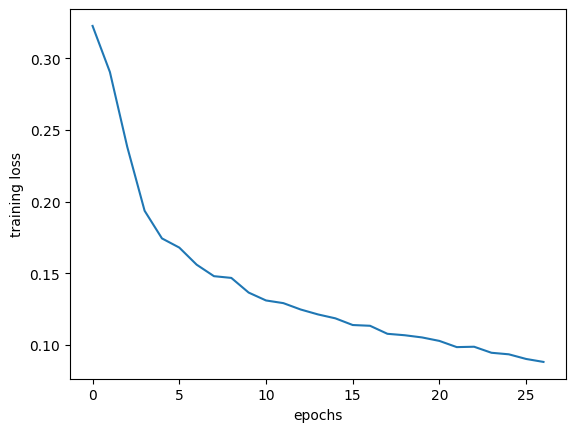

In [79]:
plt.plot(train_losses) 
plt.xlabel('epochs')
plt.ylabel('training loss')